# Effective Portfolio Optimisation using Monte Carlo Simulation

Now we will assess the return and volatility i.e. Annual Mean Return and Annual Standard Deviation by generating various number of portfolio that gives random weights to stocks in the portfolio. And from that we will pick the portfolio that has maximum Sharpe Ratio and is least Volatile.


Here we will use - **1) Reliance Industries
                              2) HDFC Bank
                              3) TCS
                              4) GTL Infrastructure  
                              5) Zerodha Gold ETF**

In [ ]:
#importing necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import yfinance as yf

In [ ]:
#!pip install yfinance

In [ ]:
# Define the ticker list
tickers = [
    'RELIANCE.NS',
    'HDFCBANK.NS',
    'TCS.NS',
    'GTLINFRA.NS',
    'GOLDCASE.NS'
]

start_date = '2021-06-23'
end_date = datetime.today().strftime('%Y-%m-%d')

# Download data
raw_data = yf.download(
    tickers,
    start=start_date,
    end=end_date,
    auto_adjust=False
)

[*********************100%***********************]  5 of 5 completed


In [ ]:
# Extract adjusted closing prices
data = raw_data['Adj Close']

# Handle missing values
data = data.dropna()
data.to_csv('stock_data.csv')

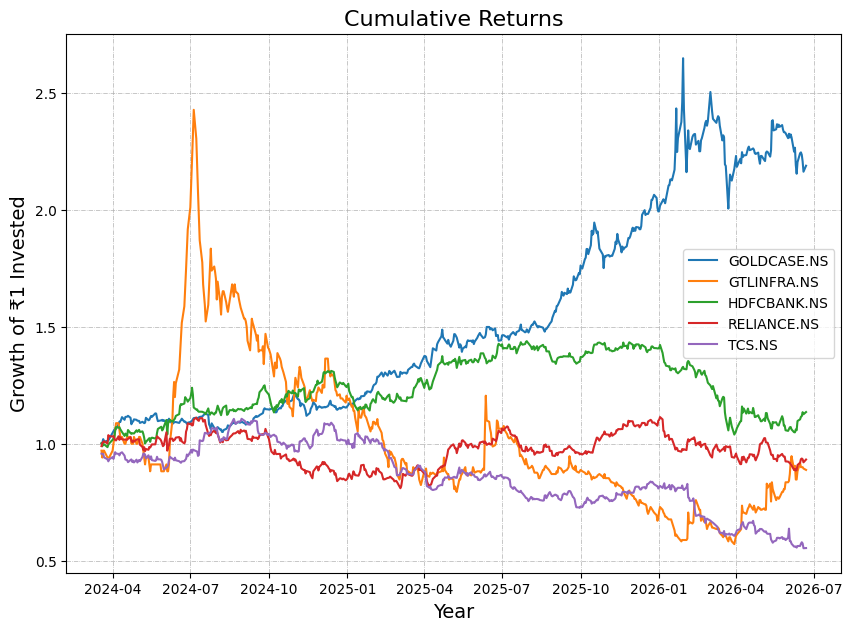

In [ ]:
cum_returns = (
    data
    .pct_change()
    .dropna()
    .add(1)
    .cumprod()
)

# Plot
plt.figure(figsize=(10, 7))

for col in cum_returns.columns:
    plt.plot(cum_returns.index, cum_returns[col], label=col)

plt.title("Cumulative Returns", fontsize=16)
plt.xlabel("Year", fontsize=14)
plt.ylabel("Growth of ₹1 Invested", fontsize=14)

plt.grid(True, linestyle='-.', linewidth=0.5)
plt.legend()

plt.show()

Now all the prerprocessing is done. Now lets calculate the Portfolio Return and Volatility.<br />
<br />
First I will calculate with equal weight to each stock

In [ ]:
data.describe()

Ticker,GOLDCASE.NS,GTLINFRA.NS,HDFCBANK.NS,RELIANCE.NS,TCS.NS
count,558.000000,558.000000,558.000000,558.000000,558.000000
mean,16.192706,1.726380,858.915199,1389.172020,3315.914315
std,4.706504,0.537391,87.865311,97.874844,547.708288
min,10.520000,0.970000,682.434814,1151.951782,2125.000000
25%,12.072500,1.420000,788.735901,1326.641144,2963.150208
50%,15.100000,1.540000,847.378906,1401.607666,3314.816284
75%,20.095000,1.987500,940.630203,1457.034760,3782.606384
max,27.879999,4.130000,996.419800,1584.971802,4253.906250


![image.png](attachment:image.png)

In [ ]:
# Calculating log daily returns
daily_return = np.log(data.pct_change() + 1).dropna()
print(daily_return)

Ticker      GOLDCASE.NS  GTLINFRA.NS  HDFCBANK.NS  RELIANCE.NS    TCS.NS
Date                                                                    
2024-03-19     0.000950    -0.029853     0.002279    -0.009931 -0.043107
2024-03-20     0.003791    -0.030772    -0.012707     0.012897 -0.001611
2024-03-21     0.015024     0.030772     0.010220     0.004992  0.000516
2024-03-22    -0.010305     0.000000    -0.002008     0.002787 -0.015741
2024-03-26     0.002821    -0.030772    -0.012168    -0.009287 -0.008577
...                 ...          ...          ...          ...       ...
2026-06-16     0.001693    -0.019418     0.009666     0.016542  0.016969
2026-06-17    -0.004664     0.000000     0.002799     0.002931  0.010855
2026-06-18    -0.012832     0.000000     0.015006    -0.003458 -0.008901
2026-06-19    -0.020001    -0.006557    -0.007919    -0.014104 -0.036184
2026-06-22     0.011788    -0.006601     0.008428     0.012899  0.001317

[557 rows x 5 columns]


In [ ]:
#Now calculating mean of those daily return
daily_return_mean = np.array(daily_return.mean())
print(daily_return_mean*100)

[ 0.14074571 -0.02127803  0.02287531 -0.01252197 -0.1060946 ]


In [ ]:
#Now assigning weights
#Since there are five stocks so each will have a weight of 0.2 (1/5)
weights = np.array([0.2,0.2,0.2,0.2,0.2])
print(weights)

[0.2 0.2 0.2 0.2 0.2]


In [ ]:
# COVARIANCE MATRIX

cov_mat = daily_return.cov()
cov_mat

Ticker,GOLDCASE.NS,GTLINFRA.NS,HDFCBANK.NS,RELIANCE.NS,TCS.NS
Ticker,,,,,
GOLDCASE.NS,2.215331e-04,0.000048,0.000030,0.000009,-9.190672e-07
GTLINFRA.NS,4.771512e-05,0.001013,0.000077,0.000103,-5.597834e-06
HDFCBANK.NS,2.959954e-05,0.000077,0.000161,0.000065,3.327172e-05
RELIANCE.NS,8.860544e-06,0.000103,0.000065,0.000185,5.262039e-05
TCS.NS,-9.190672e-07,-0.000006,0.000033,0.000053,2.100835e-04


![](https://www.wallstreetmojo.com/wp-content/uploads/2019/04/Portfolio-Return-Formula.jpg)

### Here w is weight and r is return

![image.png](attachment:image.png)

In [ ]:
#Calculating Portfolio Return
Port_return = np.sum(weights * daily_return_mean)

print('The Annual Return of Portfolio is {}%'.format((Port_return * 248)*100))
#Here 248 is multiplied for annual calculation i.e. 248 trading days in a year

The Annual Return of Portfolio is 1.1768304567261063%


In [ ]:
#Calculating Portfolio Volatility
cov = daily_return.cov()

Port_Vol = np.sqrt(weights.T @ cov_mat @ weights)


print('The Annual Volatility of Portfolio is {}%'.format((Port_Vol * np.sqrt(248))*100))

The Annual Volatility of Portfolio is 16.097865621896407%


So far we have seen the Annual Return and Annual Volatility  of Portfolio if equal weight given to each stock.<br />
<br />
Now we will perform the random generation of portfolio i.e. **Monte Carlo Simulation**

In [ ]:
#Declare the number of Portfolio to be generated
num_portfolio = 70000

#creating a empty list for storing returns,volatility,sharpe_ratio(return/volatility) and weightage of each stock in portfolio
results = np.zeros((3 + len(daily_return.columns),num_portfolio))


# Risk free rate
Risk_free_rate = 0.07

# Declaring the lower and upper bounds for weights
lower_bound = 0.0
upper_bound = 0.5


#Monte Carlo Simulation
for i in range(num_portfolio):

    while True:

        weight = np.random.rand(len(daily_return.columns)) #Declaring random weights
        weight = weight/np.sum(weight) #So that sum of all weight will be equal to 1

        if all(lower_bound <= w <= upper_bound for w in weight):
            break


    p_annual_return = np.sum(weight * daily_return_mean) * 248 #Annual Return
    p_annual_volatility = np.sqrt(np.dot(weight.T,np.dot(cov,weight))) * np.sqrt(248) #Annual Volatility

        #Storing the values in results list
    results[0,i] = p_annual_return
    results[1,i] = p_annual_volatility
    results[2,i] = (results[0,i] - Risk_free_rate)/results[1,i]

    for j in range(len(weight)):
        results[j+3,i] =  weight[j]



#Making a dataframe for results list of all generated Portfolio
cols = ['Ann_Ret','Ann_Vol','Sharpe_Ratio']
for num in range(len(list(daily_return.columns))):
    cols.append(list(daily_return.columns)[num])


result_df = pd.DataFrame(results.T,columns=cols)



In [ ]:
#Visulising the result dataframe
result_df

,Ann_Ret,Ann_Vol,Sharpe_Ratio,GOLDCASE.NS,GTLINFRA.NS,HDFCBANK.NS,RELIANCE.NS,TCS.NS
0,0.054653,0.141978,-0.108091,0.313564,0.101318,0.131781,0.268699,0.184638
1,0.001769,0.162953,-0.418714,0.114035,0.165043,0.237541,0.363626,0.119754
2,-0.011425,0.170582,-0.477333,0.192130,0.225710,0.070666,0.275773,0.235721
3,0.045299,0.186521,-0.132428,0.263173,0.282283,0.239645,0.048618,0.166280
4,0.047797,0.187982,-0.118110,0.251591,0.283436,0.219880,0.116134,0.128959
...,...,...,...,...,...,...,...,...
69995,0.074917,0.139651,0.035212,0.325152,0.044400,0.385483,0.027368,0.217596
69996,-0.049592,0.162320,-0.736769,0.165776,0.178180,0.008092,0.310147,0.337805
69997,-0.037223,0.164851,-0.650421,0.084372,0.198594,0.258116,0.215081,0.243836
69998,0.017675,0.152518,-0.343071,0.226324,0.172190,0.237462,0.129588,0.234436


In [ ]:
#locating
#Portfolio 1 - Sharpe ratio is the highest (Return/Volatility)
#Portfolio 2 - Volatility is the lowest


#Portfolio 1
max_sharpe_ratio = result_df.iloc[result_df['Sharpe_Ratio'].idxmax()]

#Portfolio 2
volatility_lowest = result_df.iloc[result_df['Ann_Vol'].idxmin()]

/tmp/ipykernel_507/2593954967.py:6: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  plt.scatter(max_sharpe_ratio[1],max_sharpe_ratio[0],marker = (5,1,3),color='red',s=700) #Red - Portfolio 1
/tmp/ipykernel_507/2593954967.py:7: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  plt.scatter(volatility_lowest[1],volatility_lowest[0],marker = (5,1,3),color='green',s=700)#Green - Portfolio 2


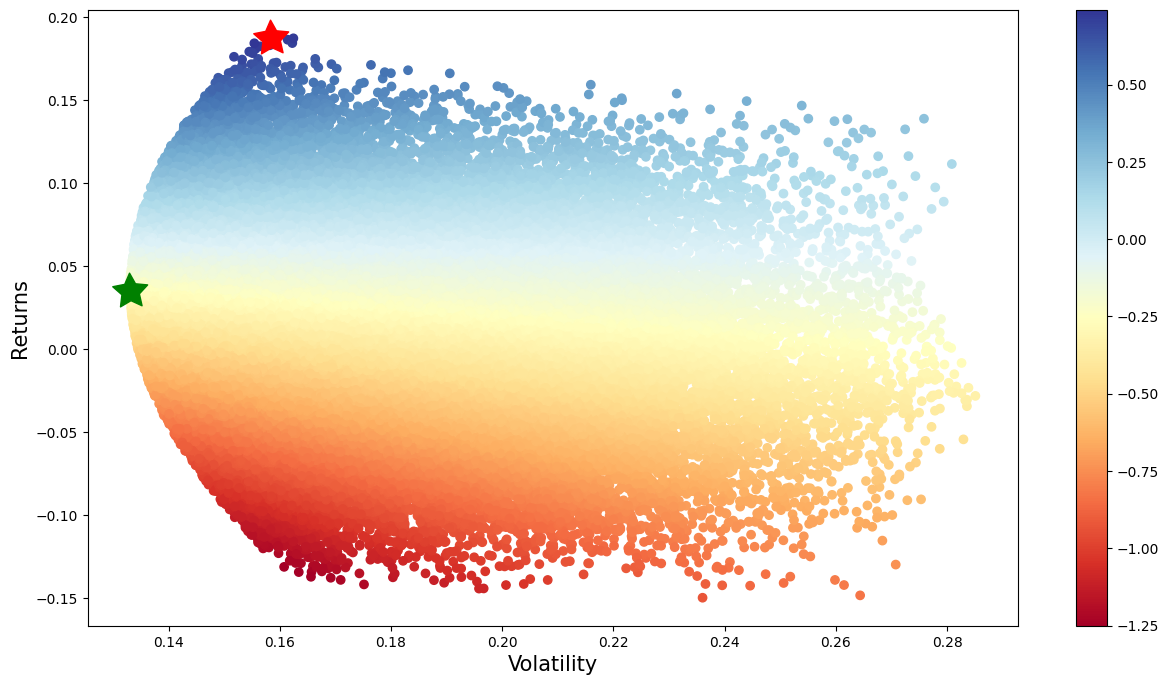

In [ ]:
#Plotting the simulation
plt.figure(figsize=(15,8))
plt.scatter(result_df['Ann_Vol'],result_df['Ann_Ret'],c =result_df['Sharpe_Ratio'],cmap='RdYlBu')
plt.colorbar()

plt.scatter(max_sharpe_ratio[1],max_sharpe_ratio[0],marker = (5,1,3),color='red',s=700) #Red - Portfolio 1
plt.scatter(volatility_lowest[1],volatility_lowest[0],marker = (5,1,3),color='green',s=700)#Green - Portfolio 2


plt.xlabel('Volatility',fontsize = 15)
plt.ylabel('Returns',fontsize = 15)
plt.show()

   # Conclusion:

In [ ]:
print('The Portfolio with maximum Return(or Sharpe_Ratio) is:')
print(round(max_sharpe_ratio,3))

The Portfolio with maximum Return(or Sharpe_Ratio) is:
Ann_Ret         0.188
Ann_Vol         0.158
Sharpe_Ratio    0.742
GOLDCASE.NS     0.479
GTLINFRA.NS     0.005
HDFCBANK.NS     0.447
RELIANCE.NS     0.058
TCS.NS          0.010
Name: 52075, dtype: float64


In [ ]:
print('The Portfolio with least Volatility is:')
print(round(volatility_lowest,3))

The Portfolio with least Volatility is:
Ann_Ret         0.035
Ann_Vol         0.133
Sharpe_Ratio   -0.260
GOLDCASE.NS     0.277
GTLINFRA.NS     0.019
HDFCBANK.NS     0.248
RELIANCE.NS     0.197
TCS.NS          0.259
Name: 17367, dtype: float64
